# Week 8 Jupyter Notebook — K-Nearest Neighbors

## Objective

This notebook applies Week 8 K-Nearest Neighbors methods to my airline delay capstone project. The target variable is `DEP_DEL15`, which shows whether a flight was delayed by at least 15 minutes.

For this week, I tested KNN with different numbers of neighbors and different distance metrics. I also compared unscaled and scaled KNN because KNN depends directly on distances between observations.

Project: Predicting U.S. airline delay risk using 2019 airline data.


In [13]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


## 1. Load the datasets

The main modeling data comes from the Kaggle `train.csv` file. The BTS `Flight_Delay.csv` file is included as supporting context, but this notebook mainly models the flight-level Kaggle data.

KNN can be slow on very large datasets because it has to compare distances between observations, so I use a smaller sample size than some of the earlier notebooks.


In [14]:
SAMPLE_SIZE = 30000
RANDOM_STATE = 42

train = pd.read_csv("data/train.csv", nrows=SAMPLE_SIZE)


try:
    delay = pd.read_csv("data/Flight_delay.csv")
    print("BTS delay file shape:", delay.shape)
except FileNotFoundError:
    print("BTS delay file not found. Continuing with Kaggle train.csv only.")

print("Train shape:", train.shape)
train.head()


BTS delay file shape: (484551, 29)
Train shape: (30000, 30)


,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


## 2. Quick EDA

The target variable is `DEP_DEL15`.

- `0` means the flight was not delayed by 15 or more minutes.
- `1` means the flight was delayed by 15 or more minutes.

This check helps show whether the classes are balanced. If the delayed class is much smaller, then accuracy alone is not enough to evaluate the model.


Target counts:
DEP_DEL15
0    24332
1     5668
Name: count, dtype: int64

Target percentage:
DEP_DEL15
0    81.11
1    18.89
Name: proportion, dtype: float64


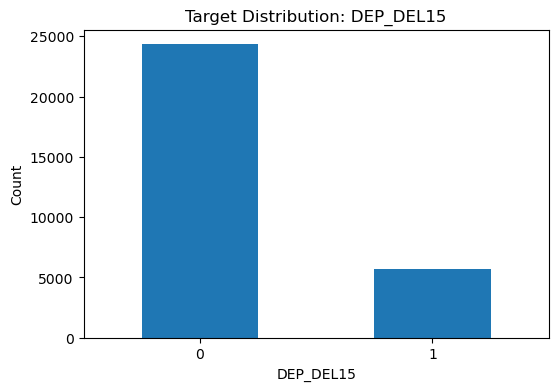

Delay rate: 0.1889


In [15]:
target = "DEP_DEL15"

print("Target counts:")
print(train[target].value_counts(dropna=False))

print("\nTarget percentage:")
print((train[target].value_counts(normalize=True, dropna=False) * 100).round(2))

delay_rate = train[target].mean()

plt.figure(figsize=(6, 4))
train[target].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution: DEP_DEL15")
plt.xlabel("DEP_DEL15")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

print("Delay rate:", round(delay_rate, 4))


## 3. Select features

I used the same main numeric features from the earlier notebooks. These include schedule, weather, airport, carrier, and historical delay variables.

For KNN, I kept this notebook numeric-only because distance calculations are easier to interpret with numeric variables.


In [16]:
target = "DEP_DEL15"

numeric_candidates = [
    "MONTH",
    "DAY_OF_WEEK",
    "DISTANCE_GROUP",
    "SEGMENT_NUMBER",
    "CONCURRENT_FLIGHTS",
    "NUMBER_OF_SEATS",
    "AIRPORT_FLIGHTS_MONTH",
    "AIRLINE_FLIGHTS_MONTH",
    "AIRLINE_AIRPORT_FLIGHTS_MONTH",
    "AVG_MONTHLY_PASS_AIRPORT",
    "AVG_MONTHLY_PASS_AIRLINE",
    "FLT_ATTENDANTS_PER_PASS",
    "GROUND_SERV_PER_PASS",
    "PLANE_AGE",
    "LATITUDE",
    "LONGITUDE",
    "PRCP",
    "SNOW",
    "SNWD",
    "TMAX",
    "AWND",
    "CARRIER_HISTORICAL",
    "DEP_AIRPORT_HIST",
    "DAY_HISTORICAL",
    "DEP_BLOCK_HIST"
]

features = [col for col in numeric_candidates if col in train.columns]

print("Target:", target)
print("Number of features used:", len(features))
print(features)


Target: DEP_DEL15
Number of features used: 25
['MONTH', 'DAY_OF_WEEK', 'DISTANCE_GROUP', 'SEGMENT_NUMBER', 'CONCURRENT_FLIGHTS', 'NUMBER_OF_SEATS', 'AIRPORT_FLIGHTS_MONTH', 'AIRLINE_FLIGHTS_MONTH', 'AIRLINE_AIRPORT_FLIGHTS_MONTH', 'AVG_MONTHLY_PASS_AIRPORT', 'AVG_MONTHLY_PASS_AIRLINE', 'FLT_ATTENDANTS_PER_PASS', 'GROUND_SERV_PER_PASS', 'PLANE_AGE', 'LATITUDE', 'LONGITUDE', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'AWND', 'CARRIER_HISTORICAL', 'DEP_AIRPORT_HIST', 'DAY_HISTORICAL', 'DEP_BLOCK_HIST']


## 4. Prepare train and validation data

I split the data into training and validation sets. I used stratification so the delayed and non-delayed classes stay in a similar proportion in both sets.


In [17]:
# Keep only the target and selected numeric features.
model_data = train[features + [target]].copy()

# Remove missing values so the models can run cleanly.
model_data = model_data.dropna()

X = model_data[features]
y = model_data[target].astype(int)

print("Modeling data shape:", model_data.shape)
print("Delay rate:", round(y.mean(), 4))

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_valid.shape[0])


Modeling data shape: (30000, 26)
Delay rate: 0.1889
Training rows: 22500
Validation rows: 7500


## 5. Baseline model

Before using KNN, I created a simple baseline model. This predicts the most common class. It gives a basic comparison point so I can tell whether KNN is actually learning useful signal.


In [18]:
def evaluate_classifier(model, X_valid, y_valid, label):
    preds = model.predict(X_valid)

    # Some models have predict_proba, which lets us calculate ROC-AUC.
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_valid)[:, 1]
        auc = roc_auc_score(y_valid, probs)
    else:
        probs = None
        auc = np.nan

    return {
        "Model": label,
        "Accuracy": accuracy_score(y_valid, preds),
        "Precision": precision_score(y_valid, preds, zero_division=0),
        "Recall": recall_score(y_valid, preds, zero_division=0),
        "F1": f1_score(y_valid, preds, zero_division=0),
        "ROC_AUC": auc
    }

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_results = evaluate_classifier(baseline, X_valid, y_valid, "Baseline: most frequent class")
pd.DataFrame([baseline_results])


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline: most frequent class,0.811067,0.0,0.0,0.0,0.5


## 6. KNN without scaling vs. KNN with scaling

KNN uses distance between observations. Because some variables have much larger numeric ranges than others, scaling is important. Without scaling, large-range variables can dominate the distance calculation.

I tested the same KNN model twice:

1. Without feature scaling
2. With standard scaling


In [19]:
X_train_knn = np.ascontiguousarray(X_train.values, dtype=np.float64)
X_valid_knn = np.ascontiguousarray(X_valid.values, dtype=np.float64)

knn_unscaled = KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2)
knn_unscaled.fit(X_train_knn, y_train)

knn_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2))
])

knn_scaled.fit(X_train_knn, y_train)

results = [
    baseline_results,
    evaluate_classifier(knn_unscaled, X_valid_knn, y_valid, "KNN unscaled, k=5, Euclidean"),
    evaluate_classifier(knn_scaled, X_valid_knn, y_valid, "KNN scaled, k=5, Euclidean")
]

results_df = pd.DataFrame(results)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline: most frequent class,0.8111,0.0000,0.0000,0.0000,0.5000
1,"KNN unscaled, k=5, Euclidean",0.7827,0.2659,0.0854,0.1293,0.5322
2,"KNN scaled, k=5, Euclidean",0.7895,0.3354,0.1164,0.1729,0.5915


<Figure size 1000x500 with 0 Axes>

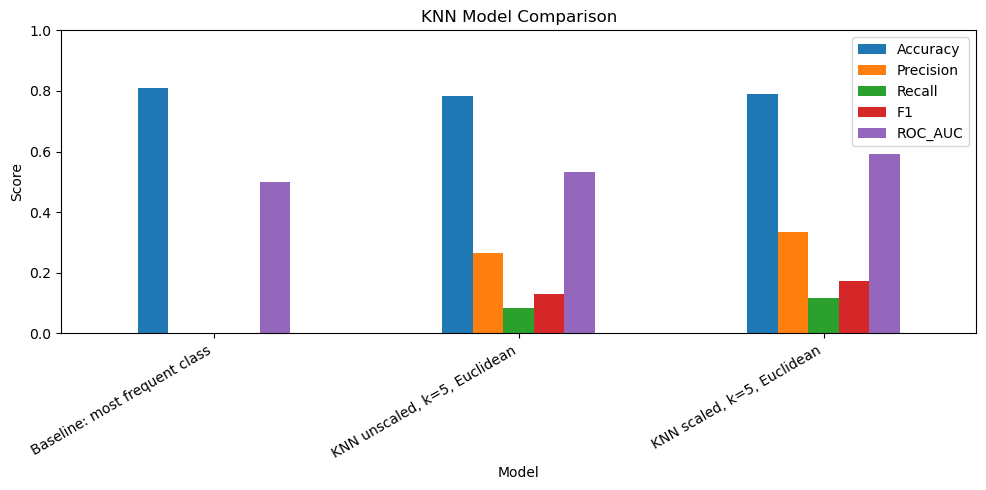

In [20]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]

plot_df = results_df.set_index("Model")[metrics_to_plot]

plt.figure(figsize=(10, 5))
plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("KNN Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(loc="best")
plt.tight_layout()
plt.show()


## 7. Tune number of neighbors and distance metrics

For KNN, the main hyperparameters I tested were:

- `n_neighbors`: how many nearby observations vote on the prediction
- `metric`: how distance is measured
- `weights`: whether each neighbor counts equally or closer neighbors count more

A smaller `k` can overfit because the model may react too much to local noise. A larger `k` can be smoother, but it may underfit if too many neighbors are averaged together.


In [21]:
k_values = [3, 5, 11, 21, 41]
metrics = ["euclidean", "manhattan"]
weights_options = ["uniform", "distance"]

tuning_results = []

for k in k_values:
    for metric in metrics:
        for weights in weights_options:
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("knn", KNeighborsClassifier(
                    n_neighbors=k,
                    metric=metric,
                    weights=weights
                ))
            ])

            model.fit(X_train, y_train)
            row = evaluate_classifier(
                model,
                X_valid,
                y_valid,
                f"KNN k={k}, metric={metric}, weights={weights}"
            )
            row["k"] = k
            row["metric"] = metric
            row["weights"] = weights
            tuning_results.append(row)

tuning_df = pd.DataFrame(tuning_results)
tuning_df.sort_values("ROC_AUC", ascending=False).round(4).head(10)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,k,metric,weights
19,"KNN k=41, metric=manhattan, weights=distance",0.8117,0.6471,0.0078,0.0153,0.6568,41,manhattan,distance
17,"KNN k=41, metric=euclidean, weights=distance",0.8108,0.4667,0.0099,0.0194,0.6565,41,euclidean,distance
18,"KNN k=41, metric=manhattan, weights=uniform",0.8112,0.5556,0.0035,0.0070,0.6551,41,manhattan,uniform
16,"KNN k=41, metric=euclidean, weights=uniform",0.8108,0.4615,0.0085,0.0166,0.6546,41,euclidean,uniform
15,"KNN k=21, metric=manhattan, weights=distance",0.8115,0.5205,0.0268,0.0510,0.6434,21,manhattan,distance
14,"KNN k=21, metric=manhattan, weights=uniform",0.8117,0.5424,0.0226,0.0434,0.6415,21,manhattan,uniform
13,"KNN k=21, metric=euclidean, weights=distance",0.8123,0.5437,0.0395,0.0737,0.6402,21,euclidean,distance
12,"KNN k=21, metric=euclidean, weights=uniform",0.8128,0.5714,0.0367,0.0690,0.6376,21,euclidean,uniform
9,"KNN k=11, metric=euclidean, weights=distance",0.8063,0.4231,0.0699,0.1199,0.6260,11,euclidean,distance
8,"KNN k=11, metric=euclidean, weights=uniform",0.8075,0.4405,0.0706,0.1217,0.6222,11,euclidean,uniform


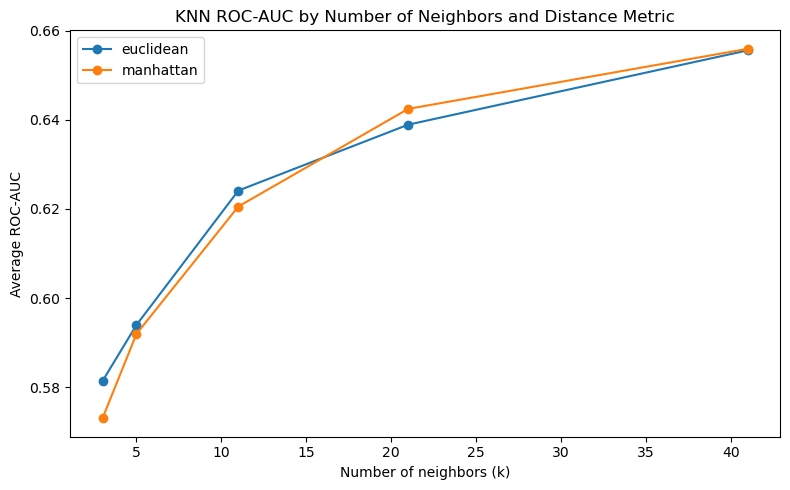

In [22]:
# Show average ROC-AUC by k and distance metric.
avg_by_k_metric = (
    tuning_df
    .groupby(["k", "metric"])["ROC_AUC"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
for metric in avg_by_k_metric["metric"].unique():
    temp = avg_by_k_metric[avg_by_k_metric["metric"] == metric]
    plt.plot(temp["k"], temp["ROC_AUC"], marker="o", label=metric)

plt.title("KNN ROC-AUC by Number of Neighbors and Distance Metric")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Average ROC-AUC")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Best KNN model

I selected the best KNN model by validation ROC-AUC because this problem is imbalanced and ROC-AUC gives a better view of ranking delayed versus non-delayed flights than accuracy alone.


In [23]:
best_row = tuning_df.sort_values("ROC_AUC", ascending=False).iloc[0]

best_k = int(best_row["k"])
best_metric = best_row["metric"]
best_weights = best_row["weights"]

print("Best KNN settings:")
print("k:", best_k)
print("metric:", best_metric)
print("weights:", best_weights)

best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=best_k,
        metric=best_metric,
        weights=best_weights
    ))
])

best_knn.fit(X_train, y_train)

best_results = evaluate_classifier(best_knn, X_valid, y_valid, "Best tuned KNN")
pd.DataFrame([best_results]).round(4)


Best KNN settings:
k: 41
metric: manhattan
weights: distance


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Best tuned KNN,0.8117,0.6471,0.0078,0.0153,0.6568


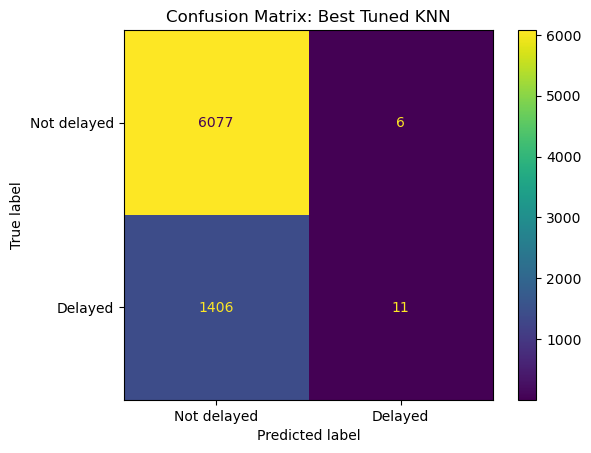

Confusion matrix:
[[6077    6]
 [1406   11]]


In [24]:
best_preds = best_knn.predict(X_valid)

cm = confusion_matrix(y_valid, best_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not delayed", "Delayed"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix: Best Tuned KNN")
plt.show()

print("Confusion matrix:")
print(cm)


## Week 8 conclusion

KNN was useful because it tested whether flights with similar numeric patterns also had similar delay outcomes. The model depended heavily on scaling because KNN is distance-based. This matched the expectation that scaling would matter when features have different units and ranges.

The tuned KNN model gave a direct comparison of neighbor count, distance metric, and weighting. In general, changing these settings affected the balance between overfitting and underfitting. A very small `k` could be too sensitive to noise, while a larger `k` made the model smoother.

For my project, KNN was useful as a comparison model, but it was not necessarily the most practical final model. It can be slower on large airline datasets, and it does not provide feature importance as directly as tree-based models. The main takeaway is that similar flights do contain some signal for delay risk, but KNN is less interpretable and less scalable than models such as random forest or gradient boosting.